In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append("../")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_

hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = hdf.keys()

These are the 8 segments we are trying to extract data from to train models on.

In [2]:
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

To illustrate how they look, here is a graph of each of them from a single battery:

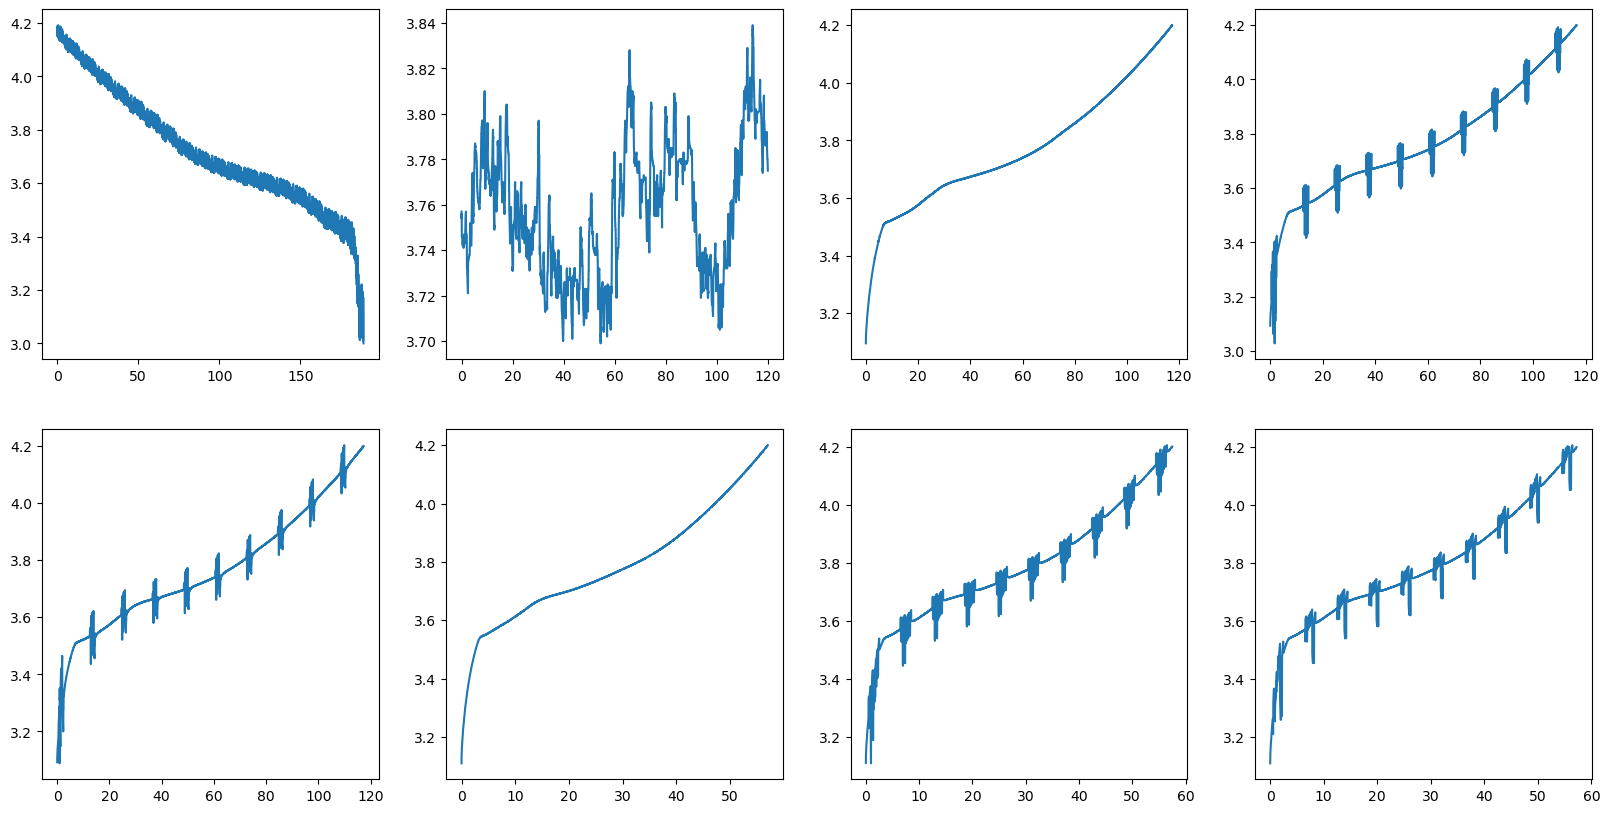

In [3]:
idx_A = np.nonzero(["_A_" in key for key in keys])
df = hdf.get(keys[idx_A[0][0]])

fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
for i, segment in enumerate(segments_of_interest):
    # filter df for any rows where the col 'Segment Description' contains segment
    df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'])

The first two, the charge depleting cycle and the charge sustaining cycle are the most unique, so extracting them takes the most effort. Usually, these two data sets are nice and regular, featuring voltage data taken either every second or every four seconds. However, there are occasional gaps in the data, and occasional extra data points between these regular intervals. Thus, the code to extract them must account for this. 

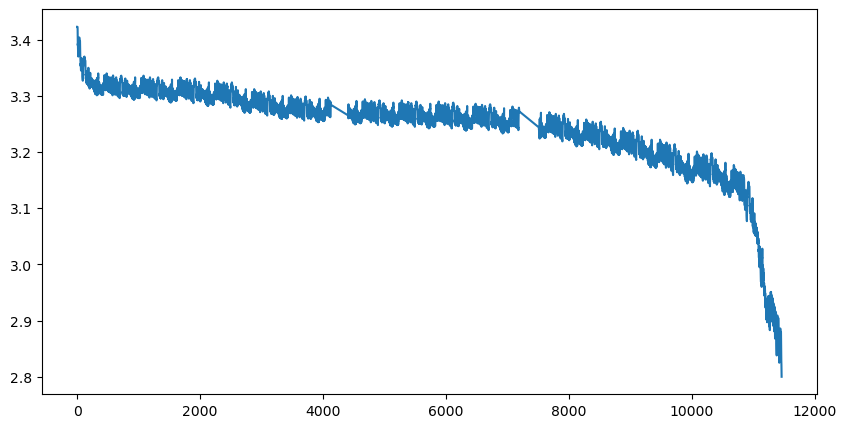

In [43]:
df = hdf.get('/D/data_240820_ReCellML_A123_cell27_charac_30oC')

df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Segment Time, S'], df[col_voltage])

Zooming in on the discontinuities, you can see the lack of data

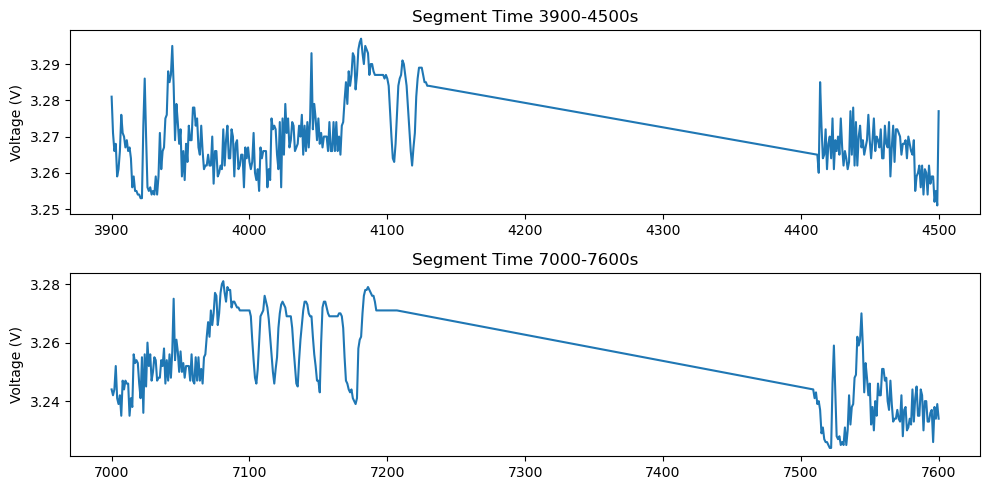

In [46]:
df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax = ax.flatten()
df1 = df[df['Segment Time, S'].between(3900, 4500)]
df2 = df[df['Segment Time, S'].between(7000, 7600)]
ax[0].plot(df1['Segment Time, S'], df1[col_voltage])
ax[1].plot(df2['Segment Time, S'], df2[col_voltage])
ax[0].set_title('Segment Time 3900-4500s')
ax[1].set_title('Segment Time 7000-7600s')
ax[0].set_ylabel('Voltage (V)')
ax[1].set_ylabel('Voltage (V)')


fig.tight_layout()

Here is an example of an extra datapoint:

Text(0.5, 0, 'Segment Time (s)')

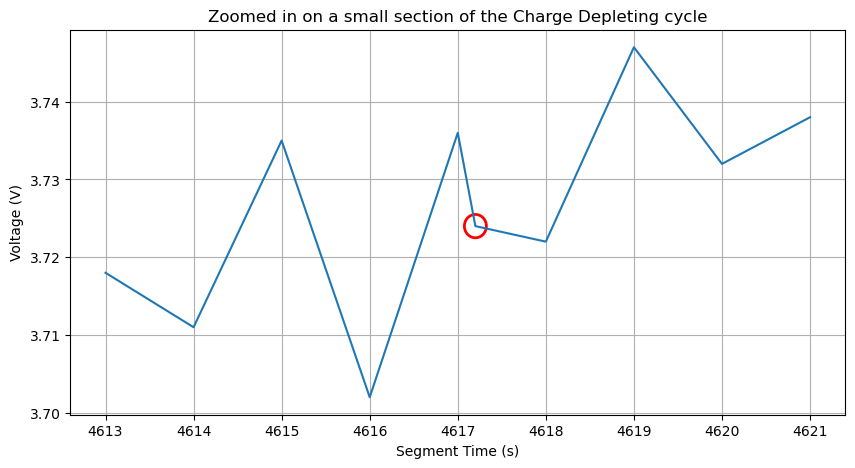

: 

In [ ]:
import matplotlib.patches as patches

df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

time = df['Segment Time, S']

fig, ax = plt.subplots(figsize=(10, 5))
section = df[(df['Total Time, S'] >=369725.6) & (df['Total Time, S'] <= 369733.6)]
# section
ax.plot(section['Segment Time, S'], section[col_voltage])
ax.grid(True)
circle = patches.Ellipse((4617.2, 3.724), 0.25, 0.003, color='red', fill=False, linewidth=2)

# Add the circle to the axes
ax.add_patch(circle)

ax.set_title('Zoomed in on a small section of the Charge Depleting cycle')
ax.set_ylabel('Voltage (V)')
ax.set_xlabel('Segment Time (s)')

Once collated across cell types, the charge depleting cycle is periodic, and repeats every 599 seconds consistently. This can be demonstrated with the following graph:

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_21268\2083933553.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


Text(0.5, 1.0, 'Type A charge depleting cycle voltage profiles colored by SOC')

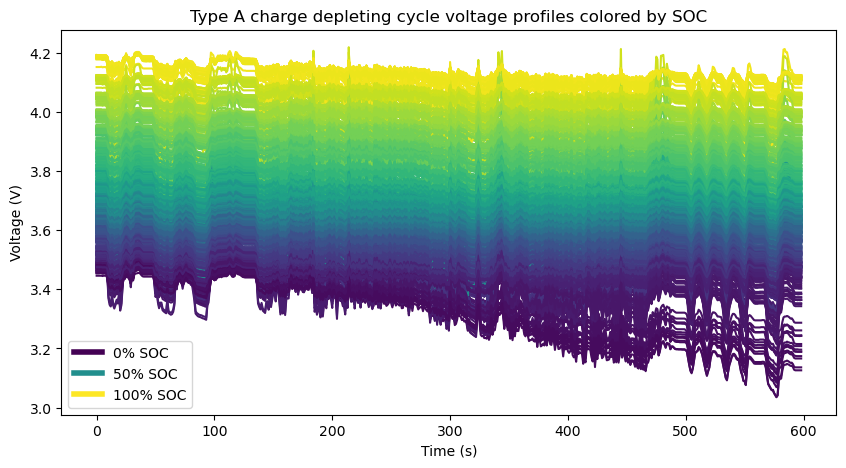

In [24]:
df = pd.read_csv('../../data/features_charge_depleting_cycles.csv')
df_a = df[df['cell_id'].str.contains('A')]

import matplotlib.cm as cm
cmap = cm.get_cmap('viridis', 100)

plt.figure(figsize=(10, 5))
for i, row in df_a.iterrows():
    plt.plot(range(599), row.filter(regex='^voltage'), alpha=1, c=cmap(row['soc_mean']))
    
plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Type A charge depleting cycle voltage profiles colored by SOC')

The Charge sustaining cycle looks similar if you graph the entire two hour interval for all batteries of a certain type, you can see just how similar and consistent the two hour cycle is.

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_21268\1487703235.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_a.loc[df_a['temperature'] < 25, 'temp_category'] = '15'
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_21268\1487703235.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


Text(0.5, 1.0, 'Type A charge sustaining cycle voltage profiles colored by temperature')

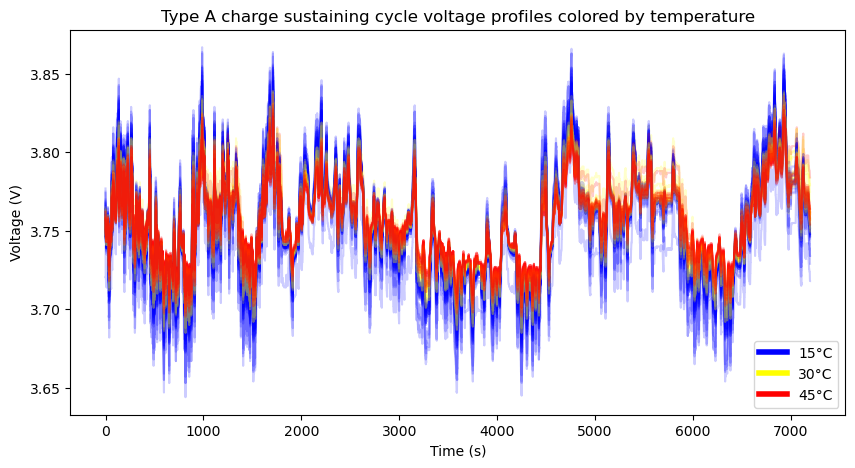

In [40]:
df = pd.read_csv('../../data/features_charge_sustaining_cycles.csv')
df_a = df[df['cell_id'].str.contains('A')]

df_a.loc[df_a['temperature'] < 25, 'temp_category'] = '15'
df_a.loc[df_a['temperature'] > 25, 'temp_category'] = '30'
df_a.loc[df_a['temperature'] > 38, 'temp_category'] = '45'
color_dict = {'15': 'blue', '30': 'yellow', '45': 'red'}

import matplotlib.cm as cm
cmap = cm.get_cmap('viridis', 100)

plt.figure(figsize=(10, 5))
for i, row in df_a.iterrows():
    plt.plot(range(7197), row.filter(regex='^voltage'), alpha=0.2, c=color_dict[row['temp_category']])

plt.legend(handles=[plt.Line2D([0], [0], color=color_dict['15'], lw=4, label='15°C'),
                    plt.Line2D([0], [0], color=color_dict['30'], lw=4, label='30°C'),
                    plt.Line2D([0], [0], color=color_dict['45'], lw=4, label='45°C')])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Type A charge sustaining cycle voltage profiles colored by temperature')

The next challenge is the extraction of the data from the other 6 pulse types, as the data is not nearly as nice to sequence. As an example, notice the inconsistent step types between each row of data. It varies from as little as 0.1 seconds to as much as 5 seconds. A different method of indexing them must be used.

In [41]:
df = hdf.get('/D/data_240626_ReCellML_A123_Cell04_charac_30C')

df = df[df['Segment Description'].str.contains('Rate test C/2 cycle charge CC')]
df.head()

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
296185,403634.8,1,1,1,1,2598,0.1,1.15,2.932,3.3,0.0,0.0,30.0,CHRG,7/1/2024 10:22:54 AM,,Rate test C/2 cycle charge CC,0.0,0.000000
296186,403635.0,1,1,1,1,2598,0.3,1.15,2.933,3.3,0.0,0.0,30.0,CHRG,7/1/2024 10:22:54 AM,,Rate test C/2 cycle charge CC,0.2,0.000027
296187,403635.1,1,1,1,1,2598,0.4,1.15,2.934,3.3,0.0,0.0,30.0,CHRG,7/1/2024 10:22:54 AM,,Rate test C/2 cycle charge CC,0.3,0.000040
296188,403635.4,1,1,1,1,2598,0.7,1.15,2.935,3.3,0.0,0.0,30.0,CHRG,7/1/2024 10:22:55 AM,,Rate test C/2 cycle charge CC,0.6,0.000080
296189,403635.7,1,1,1,1,2598,1.0,1.15,2.936,3.3,0.0,0.0,30.0,CHRG,7/1/2024 10:22:55 AM,,Rate test C/2 cycle charge CC,0.9,0.000121


After that, I can begin partitioning the data into randomized segments for training a model with. 